In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("./DATA/insurance.csv")
data.head()

In [ ]:
data.info()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:
X = data.drop(columns=["charges","insuranceclaim"],axis=1)
y = data['insuranceclaim']

In [ ]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)
smote = SMOTE(random_state=42)
X_resembled, y_resembled = smote.fit_resample(X_scaled,y)

In [ ]:
# spliting data
X_train, X_test, y_train, y_test = train_test_split(X_resembled,y_resembled,test_size=0.2,random_state=42)
model = LogisticRegression()
model.fit(X_train,y_train)

In [ ]:
# print the header
print("Insurance claim prediction")
age = float(input("Enter age in years: "))
gender = int(input("Enter your gender 1 for male and 0 for female: "))
bmi = float(input("Enter your body mass index: "))
children = int(input("Enter your number of children: "))
smoker = int(input("Are you a smoker 1 for Yes, 0 for No: "))
region = int(input("Enter your region 0 for northeast, 1 for northwest, 2 for southeast, 3 for southwest: "))
# create a dataframe for the input
user_input = pd.DataFrame([
  [age,gender,bmi,children,smoker,region]],columns=["age","sex","bmi","children","smoker","region"]
)
# scale the input
user_input_scaled = scalar.transform(user_input)
# predict the output
prediction = model.predict(user_input_scaled)
# print the output
if prediction == 1:
  print("You are likely to make an insurance claim.")
else:
  print("You are unlikely to make an insurance claim.")

## Predicting with random forest classifier

Random Forest Classifier Accuracy: 95.86%


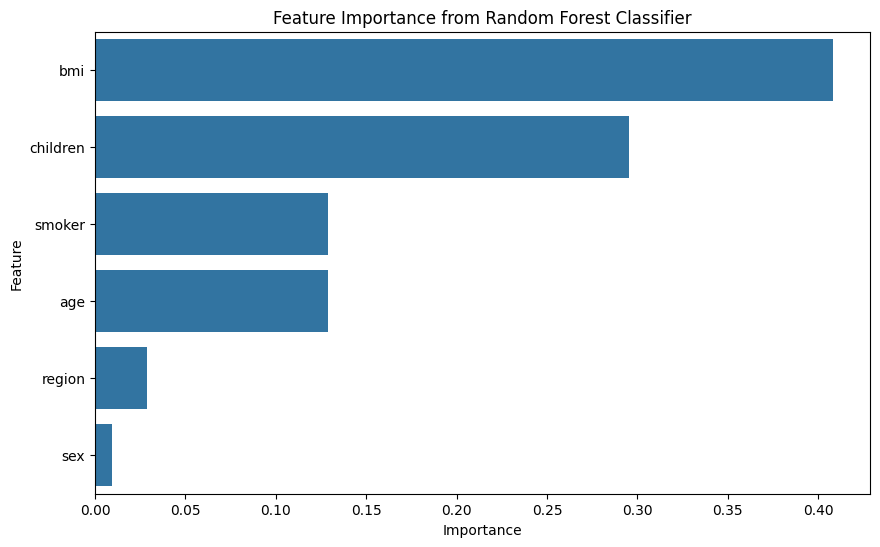

In [18]:
# random forest classifier prediction
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy * 100:.2f}%")
# Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()